In [29]:
import geopandas as gpd
import regionmask
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Precipitation data

In [2]:
ds = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/tp_MA_1940-2025_ERA5.nc')

In [3]:
ds

<xarray.Dataset> Size: 599MB
Dimensions:  (time: 1032, lat: 201, lon: 361)
Coordinates:
    number   int64 8B ...
  * time     (time) datetime64[ns] 8kB 1940-01-01T06:00:00 ... 2025-12-01T06:...
  * lat      (lat) float64 2kB 60.0 59.75 59.5 59.25 ... 10.75 10.5 10.25 10.0
  * lon      (lon) float64 3kB 40.0 40.25 40.5 40.75 ... 129.2 129.5 129.8 130.0
    expver   (time) <U4 17kB ...
Data variables:
    tp       (time, lat, lon) float64 599MB ...
Attributes:
    units:    mm/month

# Function to select one region from a shapefile with the 22 HIMAP regions

In [4]:
def himap(ds, domain):
    """
        Get the data for the corresponding zone.
        Parameters
        ----------
        domain : str
            Zone name. Options are:
            - Eastern Hindu Kush, Western Himalaya, Eastern Himalaya, 
            Central Himalaya, Karakoram, Western Pamir, Pamir Alay, 
            Northern/Western Tien Shan, Dzhungarsky Alatau, 
            Western Kunlun Shan, Nyainqentanglha, Gangdise Mountains, 
            Hengduan Shan, Tibetan Interior Mountains, Tanggula Shan, 
            Eastern Tibetan Mountains, Qilian Shan, Eastern Kunlun Shan, 
            Altun Shan, Eastern Tien Shan, Central Tien Shan, Eastern Pamir.
        ds : xarray.Dataset (or xarray.DataArray ?) 
        
        Returns
        -------
        ds_region : slice
            Data only in the wanted zone, elsewhere is NaN values.
            A grid cannot be in two different regions. 
            But some of the grids at the limits can be a little bit in the other region just next to the one chosen.
        -------
    """

    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.dims:
        if dim in ['lat', 'latitude','LAT']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LON']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    
    # Shapefile for the different regions
    shp_path = '/bettik/PROJECTS/pr-regional-climate/bricej/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp'
    shp = gpd.read_file(shp_path)

    if shp.crs != "EPSG:4326":
        shp = shp.to_crs("EPSG:4326")

    region = shp[shp["Primary_ID"] == domain]

    # masque précis
    regions = regionmask.Regions(region.geometry.values) # polygone de la région
    mask = regions.mask(ds) # masque NaN ou zéro si dans le masque
    
    ds = ds.where(mask == 0) # mask == 0 créer un masque booléen True/False pour extraire seulement la région voulue

    # découpe la zone pour alléger le dataset
    lonW, latS, lonE, latN = region.total_bounds
    if ds[lat_str][0] > ds[lat_str][-1]:
        lat_slice = slice(latN, latS)  # décroissant
    else:
        lat_slice = slice(latS, latN)  # croissant
    ds_region = ds.sel(
        {lat_str: lat_slice,
         lon_str: slice(lonW, lonE)}
    )
    
    return ds_region

# Function test

## Central Himalaya

In [5]:
ds_dom = himap(ds, 'Central Himalaya')

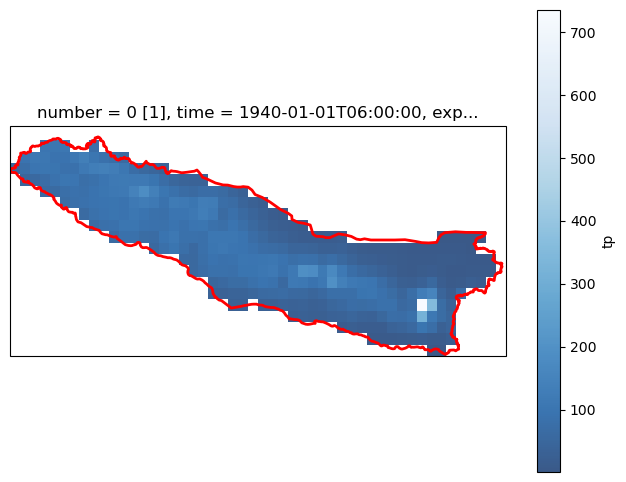

In [6]:
shp_path = '/bettik/PROJECTS/pr-regional-climate/bricej/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp'
shp = gpd.read_file(shp_path)

if shp.crs != "EPSG:4326":
    shp = shp.to_crs("EPSG:4326")

region = shp[shp["Primary_ID"] == "Central Himalaya"]

# prendre un pas de temps pour visualiser
da = ds_dom["tp"].isel(time=0)

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# champ xarray
da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Blues_r",
    add_colorbar=True, alpha=0.8
)

# contour shapefile
region.boundary.plot(
    ax=ax,
    color="red",
    linewidth=2,
    transform=ccrs.PlateCarree()
)

ax.coastlines()

plt.show()

## Gangdise Mountains (juste above Central Himalaya)

In [7]:
ds_dom = himap(ds, 'Gangdise Mountains')

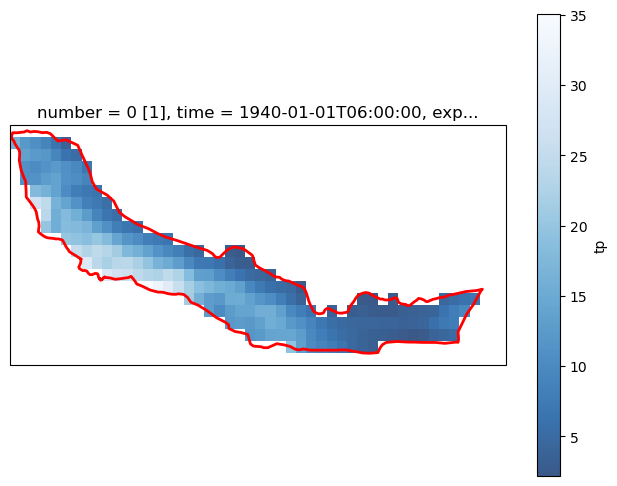

In [8]:
shp_path = '/bettik/PROJECTS/pr-regional-climate/bricej/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp'
shp = gpd.read_file(shp_path)

if shp.crs != "EPSG:4326":
    shp = shp.to_crs("EPSG:4326")

region = shp[shp["Primary_ID"] == "Gangdise Mountains"]

# prendre un pas de temps pour visualiser
da = ds_dom["tp"].isel(time=0)

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# champ xarray
da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Blues_r",
    add_colorbar=True, alpha=0.8
)

# contour shapefile
region.boundary.plot(
    ax=ax,
    color="red",
    linewidth=2,
    transform=ccrs.PlateCarree()
)

ax.coastlines()

plt.show()

# Merge HIMAP regions to have 11 regions just as Fanny

In [9]:
def himap_grouped(ds, domain_group):
    """
    Sélectionne un groupe de régions HMA.

    Parameters
    ----------
    domain_group : str
        Nom du groupe (ex: "Tien Shan", "Inner TP", etc.)
    ds : xarray.Dataset or DataArray

    Returns
    -------
    ds_region : Dataset/DataArray
    """

    # Détection des dimensions
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.dims:
        if dim in ['lat', 'latitude','LAT']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LON']:
            lon_str = dim
        else:
            other_dims_str.append(dim)

    # Grouped regions
    region_groups = {
        "Tien Shan": [
            "Eastern Tien Shan", "Dzhungarsky Alatau",
            "Northern/Western Tien Shan", "Central Tien Shan"
        ],
        "Pamir Alay": ["Pamir Alay"],
        "Pamir": ["Western Pamir"],
        "Hindu Kush": ["Eastern Hindu Kush"],
        "Karakoram": ["Karakoram"],
        "Kunlun": ["Eastern Pamir", "Western Kunlun Shan"],
        "Spiti Lahaul": ["Western Himalaya"],
        "Central Himalaya": ["Central Himalaya"],
        "Bhutan": ["Eastern Himalaya"],
        "Nyainqentangla": ["Nyainqentanglha"],
        "Inner TP": [
            "Gangdise Mountains", "Tibetan Interior Mountains",
            "Eastern Kunlun Shan", "Altun Shan", "Hengduan Shan",
            "Tanggula Shan", "Eastern Tibetan Mountains", "Qilian Shan"
        ]
    }

    # Charger shapefile
    shp_path = '/bettik/PROJECTS/pr-regional-climate/bricej/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp'
    shp = gpd.read_file(shp_path)

    if shp.crs != "EPSG:4326":
        shp = shp.to_crs("EPSG:4326")

    # Sélection multiple des régions
    region = shp[shp["Primary_ID"].isin(region_groups[domain_group])]

    # Masque
    regions = regionmask.Regions(region.geometry.values)
    mask = regions.mask(ds)
    ds = ds.where(~np.isnan(mask)) # permet de garder toutes les régions dans la région voulue

    # Limites box globale du groupe
    lonW, latS, lonE, latN = region.total_bounds

    if ds[lat_str][0] > ds[lat_str][-1]:
        lat_slice = slice(latN, latS) # décroissant 
    else:
        lat_slice = slice(latS, latN) # croissant

    ds_region = ds.sel({
        lat_str: lat_slice,
        lon_str: slice(lonW, lonE)
    })

    return ds_region

## Inner TP test

In [10]:
ds_dom = himap_grouped(ds, 'Inner TP')

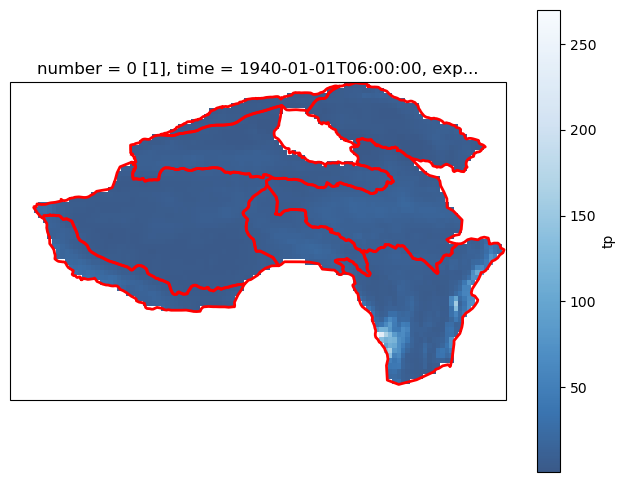

In [11]:
shp_path = '/bettik/PROJECTS/pr-regional-climate/bricej/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp'
shp = gpd.read_file(shp_path)

if shp.crs != "EPSG:4326":
    shp = shp.to_crs("EPSG:4326")

region = shp[shp["Primary_ID"].isin([
            "Gangdise Mountains", "Tibetan Interior Mountains",
            "Eastern Kunlun Shan", "Altun Shan", "Hengduan Shan",
            "Tanggula Shan", "Eastern Tibetan Mountains", "Qilian Shan"
        ])]

# prendre un pas de temps pour visualiser
da = ds_dom["tp"].isel(time=0)

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# champ xarray
da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Blues_r",
    add_colorbar=True, alpha=0.8
)

# contour shapefile
region.boundary.plot(
    ax=ax,
    color="red",
    linewidth=2,
    transform=ccrs.PlateCarree()
)

ax.coastlines()

plt.show()

## Tien Shan test

In [12]:
ds_dom = himap_grouped(ds, 'Tien Shan')

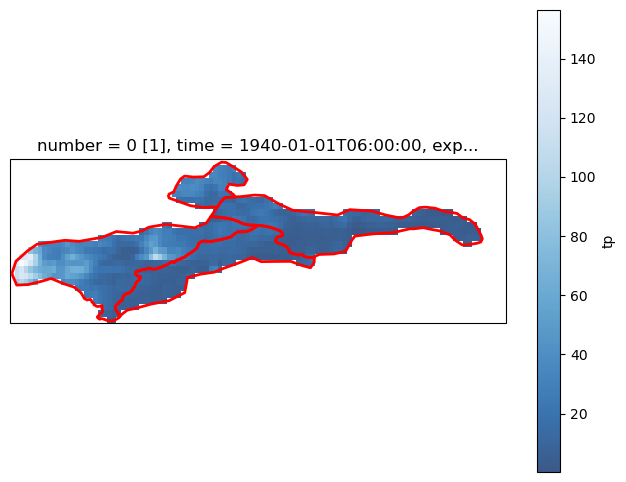

In [13]:
shp_path = '/bettik/PROJECTS/pr-regional-climate/bricej/HMA_regions_Bolch/boundary_mountain_regions_hma_v3.shp'
shp = gpd.read_file(shp_path)

if shp.crs != "EPSG:4326":
    shp = shp.to_crs("EPSG:4326")

region = shp[shp["Primary_ID"].isin([
            "Eastern Tien Shan", "Dzhungarsky Alatau",
            "Northern/Western Tien Shan", "Central Tien Shan"
        ])]

# prendre un pas de temps pour visualiser
da = ds_dom["tp"].isel(time=0)

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# champ xarray
da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Blues_r",
    add_colorbar=True, alpha=0.8
)

# contour shapefile
region.boundary.plot(
    ax=ax,
    color="red",
    linewidth=2,
    transform=ccrs.PlateCarree()
)

ax.coastlines()

plt.show()

# Test for himap function crossing regions

In [15]:
# Central Himalaya
ds_dom1 = himap(ds, 'Central Himalaya')

# Gangdise Mountains
ds_dom2 = himap(ds, 'Gangdise Mountains')

# Eastern Himalaya
ds_dom3 = himap(ds, 'Eastern Himalaya')

# Nyainqentanglha
ds_dom4 = himap(ds, 'Nyainqentanglha')

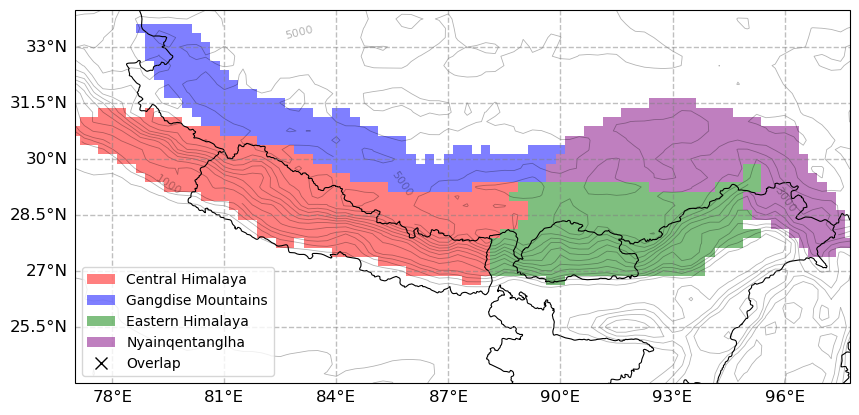

In [36]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Data Régions & couleurs

regions = {
    "Central Himalaya": (ds_dom1['tp'].isel(time=0), "red"),
    "Gangdise Mountains": (ds_dom2['tp'].isel(time=0), "blue"),
    "Eastern Himalaya": (ds_dom3['tp'].isel(time=0), "green"),
    "Nyainqentanglha": (ds_dom4['tp'].isel(time=0), "purple"),
}

masks = [] # stockage des masques binaires de régions

for name, (da, color) in regions.items():

    mask = xr.where(np.isfinite(da), 1, np.nan) # masque binaire pour chaque région
    masks.append(mask)

    # plot avec colormap une seule couleur par région
    cmap = ListedColormap([color])
    ax.pcolormesh(
        mask.lon,
        mask.lat,
        mask,
        cmap=cmap,
        vmin=0,
        vmax=1,
        shading="nearest",
        edgecolors='none',
        linewidth=0,
        alpha=0.5,
        label=name,
        transform=ccrs.PlateCarree()
    )

# Overlap (pixel commun à au moins deux régions différentes

stack = xr.concat(
    [xr.where(np.isfinite(m), 1, 0) for m in masks],
    dim="region"
)

overlap = stack.sum(dim="region") # Sum des valeurs pour chaque pixel (si >1 alors appartient à plus de 1 région)
overlap_mask = overlap >= 2

lon2d, lat2d = np.meshgrid(overlap_mask.lon,overlap_mask.lat)
ax.scatter(
    lon2d[overlap_mask],
    lat2d[overlap_mask],
    marker="x",
    color="black",
    s=15,
    linewidths=0.8,
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Topographie
elev = xr.open_dataset(
    '/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc'
)['elevation']
SH = ax.contour(
    elev.longitude,
    elev.latitude,
    elev,
    levels=[
        250,500,750,1000,1500,2000,2500,3000,
        3500,4000,4500,5000,5500,6000,6500,7000
    ],
    colors="k",
    linewidths=0.6,
    alpha=0.3,
    transform=ccrs.PlateCarree()
)
ax.clabel(SH, inline=True, fontsize=8, fmt="%d")

# Borders
ax.coastlines(linewidth=1.2)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)

# Limiter les limites de la figure
lon_min = min([d.lon.min().item() for d, _ in regions.values()])
lon_max = max([d.lon.max().item() for d, _ in regions.values()])
#lat_min = min([d.lat.min().item() for d, _ in regions.values()])
#lat_max = max([d.lat.max().item() for d, _ in regions.values()])
lat_min = 24
lat_max = 34

ax.set_extent(
    [
        lon_min,
        lon_max,
        lat_min,
        lat_max
    ],
    crs=ccrs.PlateCarree()
)

# Grid of lat & lon
#Grid of lat & lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

# legend
handles_regions = [
    mpatches.Patch(
        facecolor=color,
        edgecolor="none",
        label=name,
        alpha=0.5
    )
    for name, (_, color) in regions.items()
]
handle_overlap = mlines.Line2D(
    [],
    [],
    color="black",
    marker="x",
    linestyle="None",
    markersize=8,
    label="Overlap"
)
ax.legend(
    handles=handles_regions + [handle_overlap],
    loc="lower left",
    frameon=True
)

plt.show()